In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("titanic_dataset.csv")

In [4]:
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["sex", "embarked", "class", "who", "deck", "embark_town", "alive", "alone", "survived", "pclass"]
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive', 'alone', 'survived', 'pclass']


In [5]:
df_num = df[num_cols].dropna()

In [6]:
df_num.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


In [7]:
df["survived"]

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [11]:
df["survived_label"] = df["survived"].map({0: "No", 1: "Yes"})

In [12]:
df["survived_label"]

0       No
1      Yes
2      Yes
3      Yes
4       No
      ... 
886     No
887    Yes
888     No
889    Yes
890     No
Name: survived_label, Length: 891, dtype: str

### Numerical vs Numerical

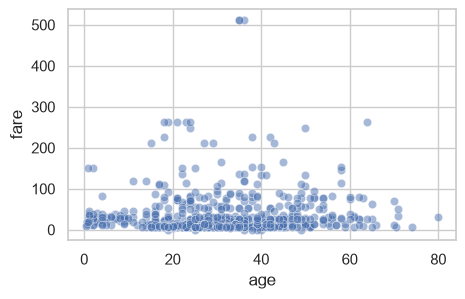

Text(0, 0.5, 'Fare')

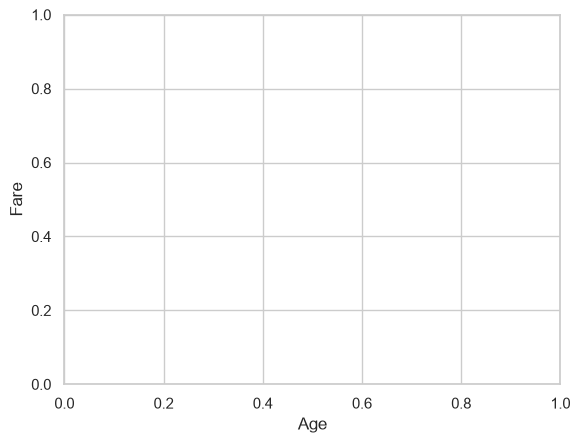

In [17]:
plt.figure(figsize=(5, 3))
sns.scatterplot(x=df["age"], y=df["fare"], alpha=0.5)
plt.show()
plt.xlabel("Age")
plt.ylabel("Fare")

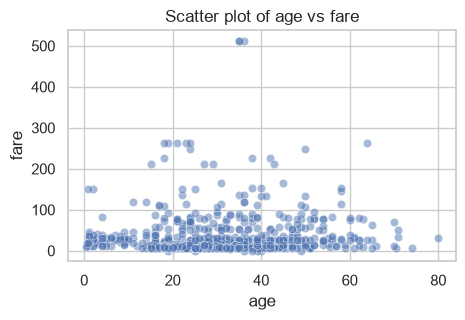

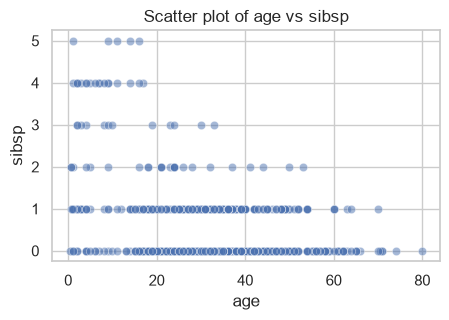

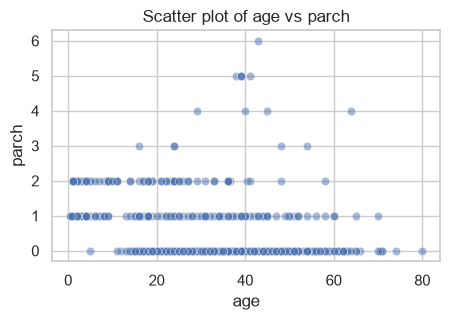

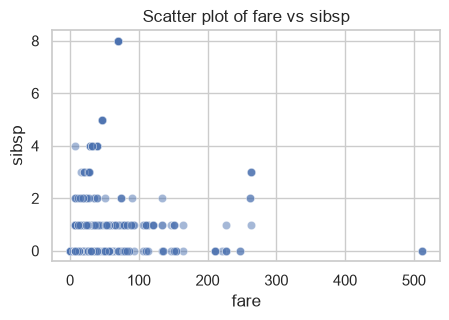

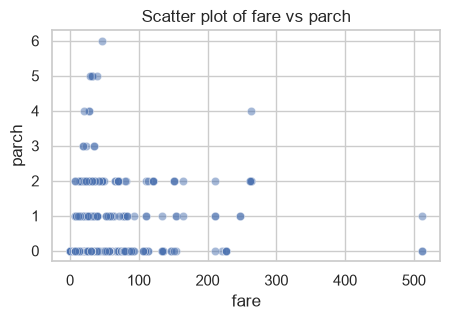

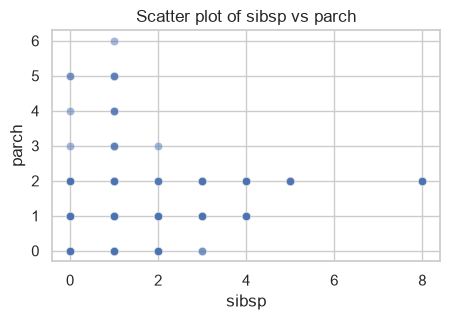

In [ ]:
num_pairs = [
    ("age", "fare"),
    ("age", "sibsp"),
    ("age", "parch"),
    ("fare", "sibsp"),
    ("fare", "parch"),
    ("sibsp", "parch")
]

for x,y in num_pairs:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(x=df[x], y=df[y], alpha=0.5)
    plt.title(f"Scatter plot of {x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

In [19]:
df_num.corr()

,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.138329,0.205119
sibsp,-0.308247,0.138329,1.000000,0.383820
parch,-0.189119,0.205119,0.383820,1.000000


In [ ]:
##-1 high negative correlation; +1 high positive correlation; 0 no correlation

In [22]:
print("Pearson correlation with fare:")

for col in num_cols:
    if col != "fare":
        r,p = pearsonr(df_num[col], df_num["fare"])
        print(f"{col} vs fare: r={r:.2f}, p={p:.4f}")

Pearson correlation with fare:
age vs fare: r=0.10, p=0.0102
sibsp vs fare: r=0.14, p=0.0002
parch vs fare: r=0.21, p=0.0000


In [23]:
df[num_cols + ["survived_label"]].groupby("survived_label").mean()

,age,fare,sibsp,parch
survived_label,,,,
No,30.626179,22.117887,0.553734,0.329690
Yes,28.343690,48.395408,0.473684,0.464912


In [25]:
for cat in ["survived_label", "sex",  "class"]:
    print(f"Summary statistics for {cat}:")
    print(df.groupby(cat)["fare"].describe())

Summary statistics for survived_label:
                count       mean        std  min      25%   50%   75%  \
survived_label                                                          
No              549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0   
Yes             342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0   

                     max  
survived_label            
No              263.0000  
Yes             512.3292  
Summary statistics for sex:
        count       mean        std   min        25%   50%    75%       max
sex                                                                        
female  314.0  44.479818  57.997698  6.75  12.071875  23.0  55.00  512.3292
male    577.0  25.523893  43.138263  0.00   7.895800  10.5  26.55  512.3292
Summary statistics for class:
        count       mean        std  min       25%      50%   75%       max
class                                                                      
First   216.0  84.154687  78.380373  0.0  30.9

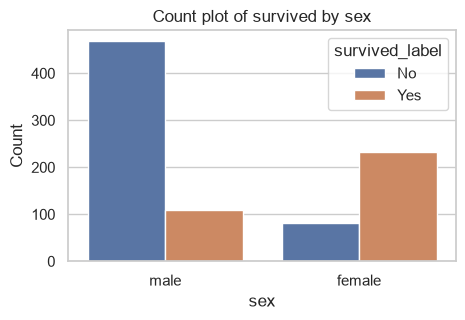

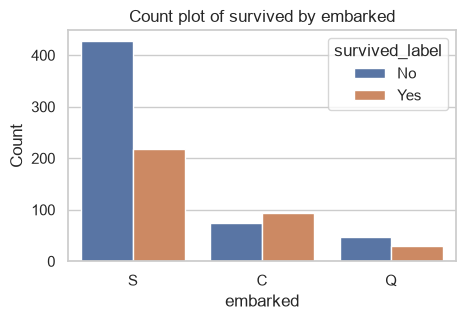

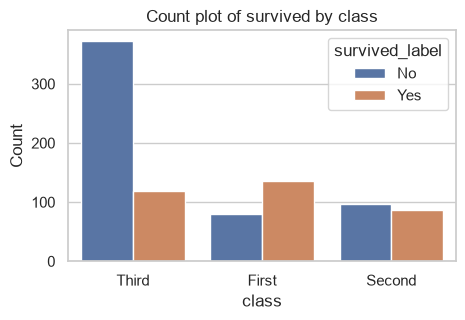

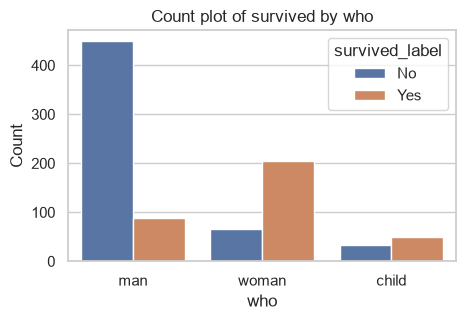

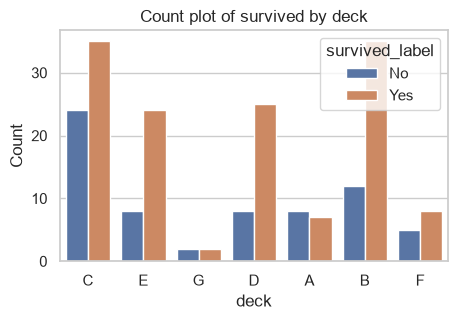

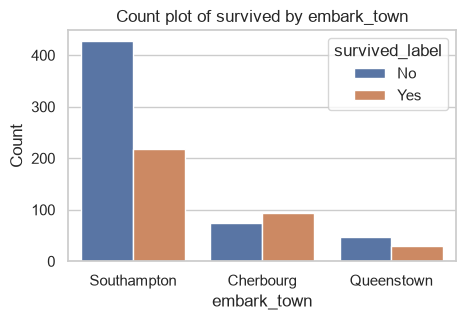

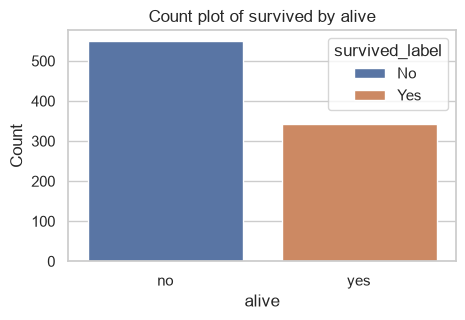

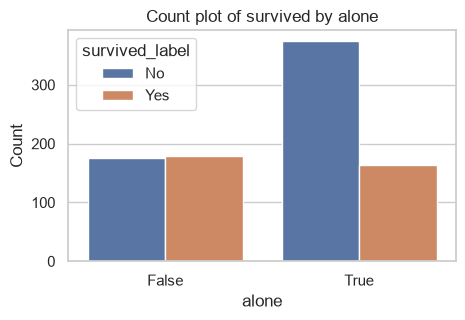

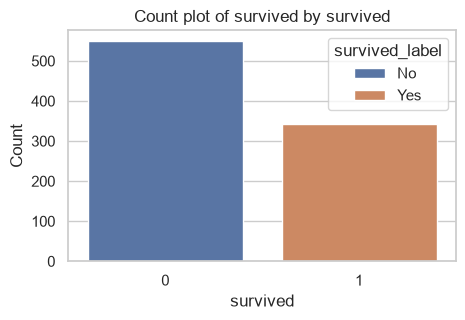

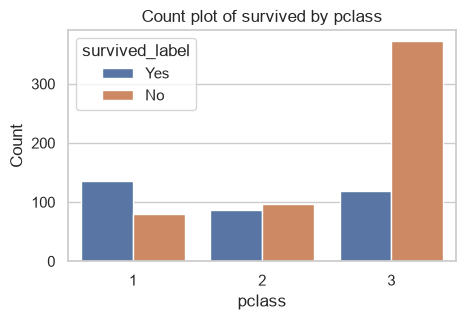

In [26]:
for col in cat_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col], hue=df["survived_label"])
    plt.title(f"Count plot of survived by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()